<a href="https://colab.research.google.com/github/khrahaman/Gradient-Inversion-Attack/blob/main/Gradient_Inversion_Attack_(Experiment_Stage).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.losses import CategoricalCrossentropy
from scipy.optimize import minimize

# --- LeNet for CIFAR-10 ---
def build_model(input_shape=(28, 28, 1), num_classes=10):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(6, (5, 5), activation='tanh', padding='valid')(inputs)
    x = tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
    x = tf.keras.layers.Conv2D(16, (5, 5), activation='tanh', padding='valid')(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(120, activation='tanh')(x)
    x = tf.keras.layers.Dense(84, activation='tanh')(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

# --- Load CIFAR-10 and prepare a sample ---
#(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
#x_true = tf.convert_to_tensor(x_train[0:1] / 255.0, dtype=tf.float32)
#y_true = tf.one_hot(y_train[0][0], 10)[None, ...]  # removes the extra dim





11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Running L-BFGS optimization...


/tmp/ipython-input-1716664362.py:57: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


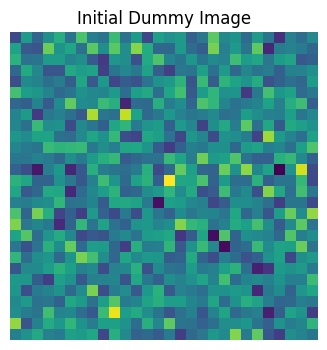

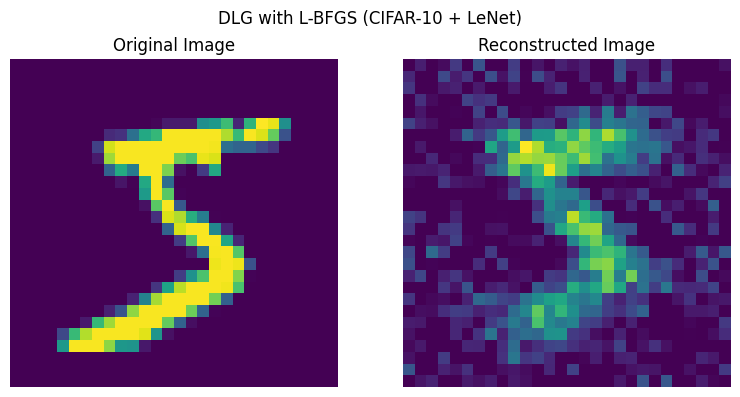

In [ ]:
#MNIST Dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
x_true = tf.convert_to_tensor(x_train[0:1] / 255.0, dtype=tf.float32)

random_index = tf.random.uniform([], minval=0, maxval=len(y_train), dtype=tf.int32)

y_true = tf.one_hot(y_train[random_index], 10)[None, ...]  # removes the extra dim


# --- Build and get true gradients ---
model = build_model()
loss_fn = CategoricalCrossentropy()

with tf.GradientTape() as tape:
    pred = model(x_true)
    loss = loss_fn(y_true, pred)
grads_target = tape.gradient(loss, model.trainable_weights)
grads_target = [g.numpy() for g in grads_target]

# --- Flatten model gradients for comparison ---
def flat_grads(grads):
    return np.concatenate([g.flatten() for g in grads])

grads_target_flat = flat_grads(grads_target)

# --- Helper: Convert dummy_x flat vector to image tensor ---
def reshape_input(flat_input):
    #return tf.reshape(flat_input, (1, 32, 32, 3))
    return tf.reshape(flat_input, (1, 28, 28, 1))

# --- Optimization objective ---
def objective(dummy_flat):
    dummy_x = tf.Variable(reshape_input(dummy_flat), dtype=tf.float32)

    with tf.GradientTape() as tape:
        pred = model(dummy_x)
        loss = loss_fn(y_true, pred)
    dummy_grads = tape.gradient(loss, model.trainable_weights)
    dummy_grads_flat = flat_grads([g.numpy() for g in dummy_grads])

    # MSE between real and dummy gradients
    grad_diff = np.mean((grads_target_flat - dummy_grads_flat) ** 2)
    return grad_diff

# --- Start from random image ---
#dummy_init = np.random.normal(0, 0.1, size=(32 * 32 * 3)).astype(np.float32)
dummy_init = np.random.normal(0, 0.1, size=(28 * 28 * 1)).astype(np.float32)

plt.figure(figsize=(8, 4))
plt.imshow(dummy_init.reshape((28, 28, 1)))
plt.title("Initial Dummy Image")
plt.axis('off')


# --- Run L-BFGS optimization ---
print("Running L-BFGS optimization...")
res = minimize(
    objective,
    dummy_init,
    method='L-BFGS-B',
    jac='2-point',  # Approximate Jacobian; fast
    options={'maxiter': 5000, 'disp': True}
)

# --- Final reconstructed image ---
reconstructed_img = reshape_input(res.x).numpy()[0]
reconstructed_img = np.clip(reconstructed_img, 0, 1)
original_img = x_true.numpy()[0]

# --- Visualize ---
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img)
plt.title("Reconstructed Image")
plt.axis('off')

plt.suptitle("DLG with L-BFGS (CIFAR-10 + LeNet)")
plt.tight_layout()
plt.show()

**Attempt 2:**

iDLG predicted label: 6 | true: 6
Running L-BFGS…
[0] grad_loss=6.342762e-05 | tv=5.557629e-02 | l2=2.511337e-01 | total=6.509491e-05


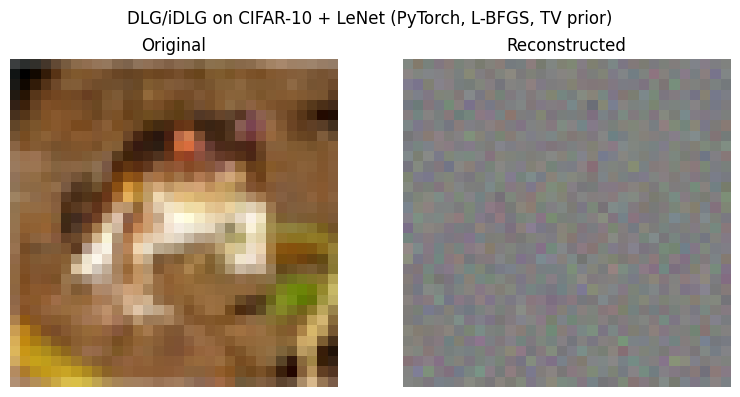

In [ ]:
# Zhu et al.'s Deep Leakage from Gradients (ICLR 2020)

# DLG / iDLG Gradient Inversion on CIFAR-10 + LeNet (PyTorch, L-BFGS, TV prior)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import LBFGS
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random

# ------------------------
# Repro & device
# ------------------------
seed = 1234
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64  # double precision helps L-BFGS

# ------------------------
# LeNet (tanh) — CIFAR-10 friendly
# ------------------------
class LeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(3, 6, kernel_size=5, padding=0)   # 32->28
        self.s2 = nn.AvgPool2d(2,2)                            # 28->14
        self.c3 = nn.Conv2d(6, 16, kernel_size=5, padding=0)  # 14->10
        self.s4 = nn.AvgPool2d(2,2)                            # 10->5
        self.f5 = nn.Linear(16*5*5, 120)
        self.f6 = nn.Linear(120, 84)
        self.fout = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.c1(x))
        x = self.s2(x)
        x = torch.tanh(self.c3(x))
        x = self.s4(x)
        x = x.view(x.size(0), -1)
        x = torch.tanh(self.f5(x))
        x = torch.tanh(self.f6(x))
        x = self.fout(x)  # logits
        return x

# ------------------------
# Data: one CIFAR-10 sample (no normalization; keep [0,1])
# ------------------------
transform = transforms.ToTensor()
ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
x_real, y_real = ds[0]  # pick any index you like
x_real = x_real.unsqueeze(0).to(device=device, dtype=dtype)   # (1,3,32,32)
y_real = torch.tensor([y_real], device=device)

# ------------------------
# Build model & get target gradients (the "leaked" gradients)
# ------------------------
model = LeNet().to(device=device, dtype=dtype)
criterion = nn.CrossEntropyLoss()

model.zero_grad(set_to_none=True)
logits = model(x_real)
loss = criterion(logits, y_real)

# target grads wrt ALL parameters
target_grads = torch.autograd.grad(loss, model.parameters(), create_graph=False, retain_graph=False)
target_grads = [g.detach().clone() for g in target_grads]  # store as constants

# ------------------------
# iDLG: infer label from last-layer bias gradient (CrossEntropy)
# ------------------------
with torch.no_grad():
    # last param is bias of fout (shape [10]); gradient ≈ p - one_hot(y)
    last_bias_grad = target_grads[-1].view(-1)  # shape [10]
    y_pred_idlg = torch.argmin(last_bias_grad).item()
print(f"iDLG predicted label: {y_pred_idlg} | true: {y_real.item()}")

y_attack = torch.tensor([y_pred_idlg], device=device)

# ------------------------
# Options / knobs
# ------------------------
match_only_early = True     # often helps: match only conv layers to start
#tv_weight = 1e-6            # TV prior (increase for smoother, decrease if too smooth)
tv_weight = 3e-5
l2_weight = 0.0             # optional pixel L2 prior
max_iter = 1000              # L-BFGS iterations
history_print_every = 20

# Choose which parameters to match (indices in model.parameters())
all_params = list(model.parameters())
if match_only_early:
    # c1.weight, c1.bias, c3.weight, c3.bias  (first 4 params)
    match_idx = [0,1,2,3]
else:
    match_idx = list(range(len(all_params)))

tgt_subset = [target_grads[i] for i in match_idx]

# ------------------------
# Priors
# ------------------------
def total_variation(x):
    # x: (B,3,32,32) in [0,1]
    diff_h = x[..., 1:, :] - x[..., :-1, :]
    diff_w = x[..., :, 1:] - x[..., :, :-1]
    return (diff_h.abs().sum() + diff_w.abs().sum()) / x.numel()

# ------------------------
# Parameterization: x = sigmoid(z) to keep in [0,1]
# ------------------------
z = torch.randn_like(x_real, dtype=dtype, device=device) * 0.1
z.requires_grad_(True)
optimizer = LBFGS([z], lr=1.0, max_iter=max_iter, history_size=100, line_search_fn="strong_wolfe")

# Precompute flattened target grads if you prefer flat matching (optional)
# Here we do per-parameter MSE; it’s more stable.

iter_count = [0]
def closure():
    optimizer.zero_grad(set_to_none=True)
    x_hat = torch.sigmoid(z)  # keep pixels in [0,1]
    logits_hat = model(x_hat)
    loss_hat = criterion(logits_hat, y_attack)

    # grads wrt the same subset of params (create_graph=True to backprop through grad)
    grads_hat = torch.autograd.grad(loss_hat, [all_params[i] for i in match_idx], create_graph=True)

    # gradient matching loss
    grad_loss = sum(F.mse_loss(gh, gt) for gh, gt in zip(grads_hat, tgt_subset))

    # image priors
    tv = total_variation(x_hat)
    l2 = (x_hat**2).mean()

    total = grad_loss + tv_weight * tv + l2_weight * l2
    total.backward()

    # progress
    if iter_count[0] % history_print_every == 0:
        with torch.no_grad():
            print(f"[{iter_count[0]}] grad_loss={grad_loss.item():.6e} | tv={tv.item():.6e} | l2={l2.item():.6e} | total={total.item():.6e}")
    iter_count[0] += 1
    return total

print("Running L-BFGS…")
optimizer.step(closure)

# ------------------------
# Results & viz
# ------------------------
with torch.no_grad():
    x_rec = torch.sigmoid(z).clamp(0,1).detach().cpu().squeeze(0).permute(1,2,0).numpy()
    x_gt  = x_real.detach().cpu().squeeze(0).permute(1,2,0).numpy()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(x_gt);  plt.title("Original");     plt.axis("off")
plt.subplot(1,2,2); plt.imshow(x_rec); plt.title("Reconstructed"); plt.axis("off")
plt.suptitle("DLG/iDLG on CIFAR-10 + LeNet (PyTorch, L-BFGS, TV prior)")
plt.tight_layout(); plt.show()


**Attempt 3:**


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
#torch.manual_seed(42)
#np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=True)

# Define the model (same as in the paper)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 3, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(3, 3, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(3 * 28 * 28, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

# Function to get real gradients from a batch
def get_real_gradients(model, criterion, images, labels):
    model.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()

    # Collect gradients
    real_gradients = []
    for param in model.parameters():
        real_gradients.append(param.grad.clone())

    return real_gradients, loss.item()


def idlg_attack(real_gradients, model, criterion, batch_size=1, num_iterations=1000, lr=0.1):
    """
    iDLG (approximate): infer one label from gradients, apply it to all dummy samples.
    For true multi-label batch recovery, more advanced methods are needed.
    """
    # -------- Step 1: Infer a label from last layer's gradient --------
    last_layer_grad = real_gradients[-2]  # fc1.weight (not bias)
    grad_sign = last_layer_grad.sum(dim=1)  # sum over features
    inferred_label = torch.argmin(grad_sign)  # iDLG: class with min sum

    print(f"[iDLG] Inferred label (applied to all samples): {inferred_label.item()}")

    # -------- Step 2: Initialize dummy images --------
    dummy_images = torch.randn(batch_size, 1, 28, 28, requires_grad=True, device=device)
    optimizer = optim.Adam([dummy_images], lr=lr)
    losses = []

    # -------- Step 3: Optimize dummy images --------
    for iteration in range(num_iterations):
        optimizer.zero_grad()
        model.zero_grad()

        dummy_outputs = model(dummy_images)
        dummy_loss = criterion(dummy_outputs, inferred_label.repeat(batch_size))

        dummy_gradients = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

        grad_loss = 0
        for d_grad, r_grad in zip(dummy_gradients, real_gradients):
            grad_loss += torch.norm(d_grad - r_grad) ** 2

        grad_loss.backward()
        optimizer.step()

        with torch.no_grad():
            dummy_images.data = torch.clamp(dummy_images.data, -3, 3)

        losses.append(grad_loss.item())
        if iteration % 100 == 0:
            print(f"Iteration {iteration}, Gradient Loss: {grad_loss.item():.6f}")

    return dummy_images.detach(), inferred_label.repeat(batch_size), losses




# Function to visualize results
def visualize_results(original_images, reconstructed_images, original_labels, reconstructed_labels):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    # Original image
    axes[0, 0].imshow(original_images[0, 0].cpu().numpy(), cmap='gray')
    axes[0, 0].set_title(f'Original Image (Label: {original_labels[0].item()})')
    axes[0, 0].axis('off')

    # Reconstructed image
    axes[0, 1].imshow(reconstructed_images[0, 0].cpu().numpy(), cmap='gray')
    axes[0, 1].set_title(f'Reconstructed Image (Label: {reconstructed_labels[0].item()})')
    axes[0, 1].axis('off')

    # Difference
    diff = torch.abs(original_images - reconstructed_images)
    axes[1, 0].imshow(diff[0, 0].cpu().numpy(), cmap='hot')
    axes[1, 0].set_title('Absolute Difference')
    axes[1, 0].axis('off')

    # Histogram of differences
    axes[1, 1].hist(diff.cpu().numpy().flatten(), bins=50)
    axes[1, 1].set_title('Difference Distribution')
    axes[1, 1].set_xlabel('Absolute Difference')
    axes[1, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Main experiment
def main():
    # Initialize model and criterion
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()

    # Get a batch of real data
    data_iter = iter(train_loader)
    real_images, real_labels = next(data_iter)
    real_images, real_labels = real_images.to(device), real_labels.to(device)

    print(f"Original image shape: {real_images.shape}")
    print(f"Original label: {real_labels.item()}")

    # Get real gradients
    real_gradients, real_loss = get_real_gradients(model, criterion, real_images, real_labels)
    print(f"Real loss: {real_loss:.4f}")

    # Perform DLG attack
    print("Starting DLG attack...")
    reconstructed_images, reconstructed_labels, losses = idlg_attack(
        real_gradients, model, criterion, num_iterations=1000, lr=0.1
    )

    # Visualize results
    visualize_results(real_images, reconstructed_images, real_labels, reconstructed_labels)

    # Plot loss curve
    plt.figure(figsize=(10, 4))
    plt.plot(losses)
    plt.title('Gradient Matching Loss During DLG Attack')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.grid(True)
    plt.show()

    # Calculate reconstruction metrics
    mse = torch.nn.functional.mse_loss(real_images, reconstructed_images).item()
    psnr = 10 * torch.log10(1 / torch.tensor(mse)).item()

    print(f"Reconstruction Metrics:")
    print(f"MSE: {mse:.6f}")
    print(f"PSNR: {psnr:.2f} dB")
    print(f"Original label: {real_labels.item()}")
    print(f"Reconstructed label: {reconstructed_labels.item()}")

if __name__ == "__main__":
    main()

Using device: cpu
Original image shape: torch.Size([10, 1, 28, 28])


RuntimeError: a Tensor with 10 elements cannot be converted to Scalar

**Attempt 4:**

Using device: cpu
Real batch shape: torch.Size([8, 1, 28, 28]), labels: [3, 6, 7, 2, 0, 9, 7, 0]
Real loss: 2.266135
Starting GradInversion-style attack...
Iter 0000: Total Loss=5.348532e-01, GradMatch=3.314287e-01, TV=2.180154e+00, Ent=1.910607e+00
Iter 0100: Total Loss=2.465122e-02, GradMatch=1.404552e-02, TV=8.960027e-01, Ent=2.055032e-02
Iter 0200: Total Loss=1.779952e-02, GradMatch=8.936551e-03, TV=6.914144e-01, Ent=7.633236e-03
Iter 0300: Total Loss=1.950651e-02, GradMatch=1.103189e-02, TV=6.586477e-01, Ent=4.245094e-03
Iter 0400: Total Loss=1.521982e-02, GradMatch=7.056092e-03, TV=6.194441e-01, Ent=2.766619e-03
Iter 0500: Total Loss=1.913349e-02, GradMatch=1.101766e-02, TV=6.285697e-01, Ent=1.971472e-03
Iter 0600: Total Loss=1.380635e-02, GradMatch=5.866220e-03, TV=6.045603e-01, Ent=1.485534e-03
Iter 0700: Total Loss=2.374048e-02, GradMatch=1.572491e-02, TV=6.371036e-01, Ent=1.165281e-03
Iter 0800: Total Loss=1.354756e-02, GradMatch=5.492079e-03, TV=6.266258e-01, Ent=9.424189e-0

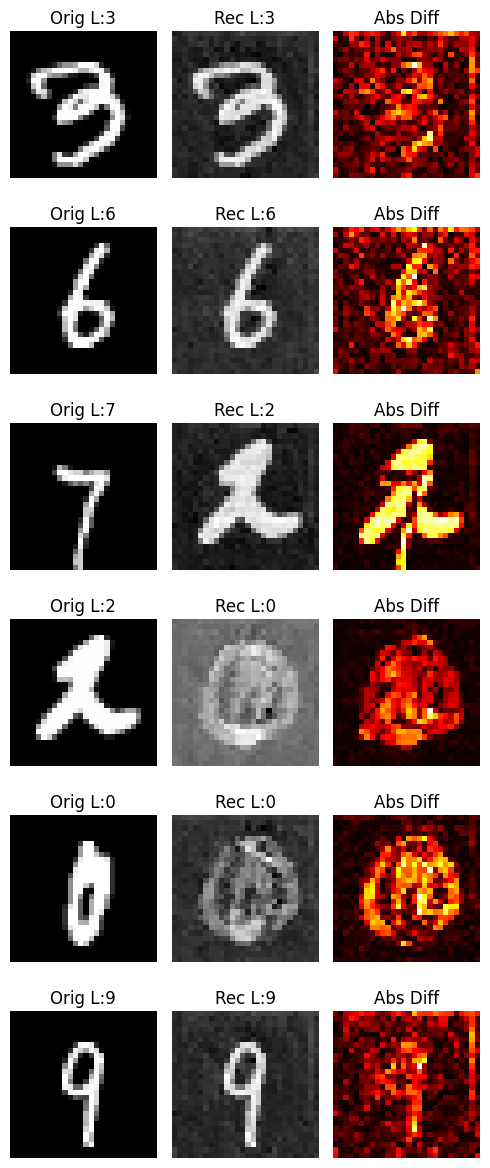

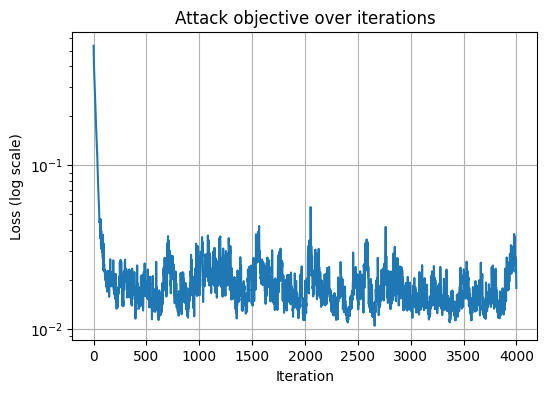

Mean MSE over batch: 7.852257e-01
Mean PSNR (est): 1.05 dB
Original labels: [3, 6, 7, 2, 0, 9, 7, 0]
Recovered labels: [3, 6, 2, 0, 0, 9, 7, 7]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters / knobs
BATCH_SIZE = 8     # (1, 8, 32, 100...)
NUM_ITERS = 4000
LR = 0.1

# Regularizers
TV_WEIGHT = 1e-3
L2_WEIGHT = 1e-2
ENTROPY_WEIGHT = 1e-1

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 3, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(3, 3, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(3 * 28 * 28, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x


class CIFAR_CNN(nn.Module):
    def __init__(self):
        super(CIFAR_CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x



# Function to get real gradients from a batch (returns list of tensors)
def get_real_gradients(model, criterion, images, labels):
    model.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()

    real_gradients = []
    for param in model.parameters():
        # If a param has grad None (shouldn't in this model), append zeros of same shape
        if param.grad is None:
            real_gradients.append(torch.zeros_like(param, device=device))
        else:
            real_gradients.append(param.grad.clone().detach())
    return real_gradients, loss.item()

# Helper: total variation (isotropic)
def total_variation(x):
    # x: [B, C, H, W]
    h_variation = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).sum()
    w_variation = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).sum()
    return (h_variation + w_variation) / x.numel()

# Soft cross-entropy (between predicted logits and soft labels probability)
def soft_cross_entropy(pred_logits, soft_targets):
    # pred_logits: [B, C], soft_targets: [B, C] (probabilities)
    log_p = F.log_softmax(pred_logits, dim=-1)
    return -(soft_targets * log_p).sum(dim=1).mean()

# GradInversion style attack: joint optimization of images + soft labels
def gradinversion_attack(real_gradients, model, criterion, batch_size, num_iterations, lr,
                         tv_weight, l2_weight, entropy_weight):
    model.to(device)
    model.eval()  # ensure deterministic behavior for BN etc (no running stats updates here)

    # Initialize dummy images and soft-label logits
    dummy_images = torch.randn(batch_size, 1, 28, 28, device=device, requires_grad=True)
    #dummy_images = torch.randn(batch_size, 3, 32, 32, device=device, requires_grad=True)
    dummy_label_logits = torch.randn(batch_size, 10, device=device, requires_grad=True)  # unnormalized logits

    # Optimizer works on both images and label logits
    optimizer = optim.Adam([dummy_images, dummy_label_logits], lr=lr)
    losses = []

    # Precompute a per-parameter normalization to balance layers (optional but helpful)
    param_norms = [g.norm() + 1e-9 for g in real_gradients]  # avoid div by zero
    layer_weights = [1.0 / pn for pn in param_norms]  # smaller real grad -> larger weight (inverse)
    # normalize layer_weights to sum to number of params so scale is comparable
    lw_sum = sum(layer_weights)
    layer_weights = [lw * len(layer_weights) / lw_sum for lw in layer_weights]
    layer_weights = [lw.to(device) if isinstance(lw, torch.Tensor) else torch.tensor(lw, device=device) for lw in layer_weights]

    for it in range(num_iterations):
        optimizer.zero_grad()
        model.zero_grad()

        # Build soft targets
        soft_targets = F.softmax(dummy_label_logits, dim=-1)  # [B, C]

        # Forward on dummy images
        outputs = model(dummy_images)
        # Soft cross-entropy between model outputs and soft targets
        dummy_loss = soft_cross_entropy(outputs, soft_targets)

        # Compute dummy gradients w.r.t. model parameters (create_graph=True so we can backprop to images/labels)
        dummy_grads = torch.autograd.grad(dummy_loss, model.parameters(), create_graph=True)

        # Gradient matching loss: layer-wise weighted squared Frobenius norm
        grad_loss = 0.0
        for dg, rg, w in zip(dummy_grads, real_gradients, layer_weights):
            # ensure both are same device & dtype
            rg = rg.to(device)
            # compute squared norm of the difference
            grad_loss = grad_loss + w * ((dg - rg).pow(2)).sum()

        # Priors / regularizers on dummy images and labels
        tv = total_variation(dummy_images)
        l2 = torch.sum(dummy_images.pow(2)) / dummy_images.numel()
        entropy = - (soft_targets * torch.log(soft_targets + 1e-12)).sum(dim=1).mean()  # target entropy (we will push to low ent)

        loss = grad_loss + tv_weight * tv + l2_weight * l2 + entropy_weight * entropy

        # Backprop to dummy images and label logits
        loss.backward()
        optimizer.step()

        # clamp images into reasonable normalized range (MNIST normalization roughly around [-3,3])
        with torch.no_grad():
            dummy_images.clamp_(-4.0, 4.0)

        losses.append(loss.item())

        if it % 100 == 0 or it == num_iterations - 1:
            print(f"Iter {it:04d}: Total Loss={loss.item():.6e}, GradMatch={grad_loss.item():.6e}, TV={tv.item():.6e}, Ent={entropy.item():.6e}")

    # Final recovered labels (hard)
    recovered_labels = torch.argmax(F.softmax(dummy_label_logits.detach(), dim=-1), dim=-1)
    return dummy_images.detach().cpu(), recovered_labels.detach().cpu(), losses

# Visualization (works with batch)
def visualize_results_batch(original_images, reconstructed_images, original_labels, reconstructed_labels, n_show=4):
    n_show = min(n_show, original_images.size(0), reconstructed_images.size(0))
    fig, axes = plt.subplots(n_show, 3, figsize=(5, 2 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    for i in range(n_show):
        axes[i, 0].imshow(original_images[i, 0].cpu().numpy(), cmap='gray')
        axes[i, 0].set_title(f'Orig L:{original_labels[i].item()}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(reconstructed_images[i, 0].cpu().numpy(), cmap='gray')
        axes[i, 1].set_title(f'Rec L:{reconstructed_labels[i].item()}')
        axes[i, 1].axis('off')

        diff = torch.abs(original_images[i] - reconstructed_images[i])
        axes[i, 2].imshow(diff[0].cpu().numpy(), cmap='hot')
        axes[i, 2].set_title('Abs Diff')
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()


def visualize_cifar(original_images, reconstructed_images, original_labels, reconstructed_labels, n_show=4):
    n_show = min(n_show, original_images.size(0), reconstructed_images.size(0))
    fig, axes = plt.subplots(n_show, 3, figsize=(5, 2 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)
    for i in range(n_show):
        axes[i, 0].imshow(original_images[i].permute(1, 2, 0).cpu().numpy())
        axes[i, 0].set_title(f'Orig L:{original_labels[i].item()}')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(reconstructed_images[i].permute(1, 2, 0).cpu().numpy())
        axes[i, 1].set_title(f'Rec L:{reconstructed_labels[i].item()}')
        axes[i, 1].axis('off')

        diff = torch.abs(original_images[i] - reconstructed_images[i])
        axes[i, 2].imshow(diff.mean(dim=0).cpu().numpy(), cmap='hot')
        axes[i, 2].set_title('Abs Diff')
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.show()


# Main experiment (uses BATCH_SIZE)
def main():
    model = SimpleCNN().to(device)
    #model = CIFAR_CNN().to(device)
    criterion = nn.CrossEntropyLoss()

    # Get a batch of real data (BATCH_SIZE)
    data_iter = iter(train_loader)
    real_images, real_labels = next(data_iter)
    real_images, real_labels = real_images.to(device), real_labels.to(device)
    print(f"Real batch shape: {real_images.shape}, labels: {real_labels.tolist()}")

    # Get real gradients from the model for this batch
    real_gradients, real_loss = get_real_gradients(model, criterion, real_images, real_labels)
    print(f"Real loss: {real_loss:.6f}")

    # Run GradInversion attack (joint optimization)
    print("Starting GradInversion-style attack...")
    rec_images, rec_labels, losses = gradinversion_attack(
        real_gradients, model, criterion,
        batch_size=BATCH_SIZE, num_iterations=NUM_ITERS, lr=LR,
        tv_weight=TV_WEIGHT, l2_weight=L2_WEIGHT, entropy_weight=ENTROPY_WEIGHT
    )

    # Visualize first few results
    visualize_results_batch(real_images.cpu(), rec_images, real_labels.cpu(), rec_labels, n_show=min(6, BATCH_SIZE))
    #visualize_cifar(real_images.cpu(), rec_images, real_labels.cpu(), rec_labels, n_show=min(6, BATCH_SIZE))

    # Loss curve
    plt.figure(figsize=(6,4))
    plt.plot(losses)
    plt.yscale('log')
    plt.title('Attack objective over iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (log scale)')
    plt.grid(True)
    plt.show()

    # Compute simple metrics per-sample (MSE)
    mse_list = []
    for i in range(BATCH_SIZE):
        mse = F.mse_loss(real_images[i].cpu(), rec_images[i]).item()
        mse_list.append(mse)
    mean_mse = float(np.mean(mse_list))
    print(f"Mean MSE over batch: {mean_mse:.6e}")
    if mean_mse > 0:
        psnr = 10 * np.log10(1.0 / mean_mse)
        print(f"Mean PSNR (est): {psnr:.2f} dB")
    else:
        print("Zero MSE (perfect) — PSNR infinite")

    print("Original labels:", real_labels.cpu().tolist())
    print("Recovered labels:", rec_labels.tolist())

if __name__ == "__main__":
    main()


**Attempt 5**

In [ ]:
"""
federated_sim.py

Federated learning simulation:
- Clients run in separate processes and are forced to use CPU only.
- Server (main process) uses GPU for aggregation & evaluation.
- Uses a LeNet-like model (the one you provided) and MNIST dataset.
"""

import os
import numpy as np
import multiprocessing as mp
from multiprocessing import Queue, Process
from functools import partial

# IMPORTANT: do not import tensorflow here in child processes until after
# we disable CUDA for those processes. We'll import TF inside worker.
# However, main process will import TF (and use GPU). Delay TF import
# in main until after we prepare data splits.

def build_lenet_model_tf(tf, input_shape=(32, 32, 3), num_classes=10):
    # Builds the LeNet model using the provided tensorflow (tf) module.
    from tensorflow.keras.layers import Input, Conv2D, AveragePooling2D, Flatten, Dense
    from tensorflow.keras.models import Model

    inputs = Input(shape=input_shape)
    x = Conv2D(6, (5, 5), activation='tanh', padding='valid', name='C1')(inputs)
    x = AveragePooling2D(pool_size=(2, 2), name='S2')(x)
    x = Conv2D(16, (5, 5), activation='tanh', padding='valid', name='C3')(x)
    x = AveragePooling2D(pool_size=(2, 2), name='S4')(x)
    x = Flatten(name='Flatten')(x)
    x = Dense(120, activation='tanh', name='F5')(x)
    x = Dense(84, activation='tanh', name='F6')(x)
    outputs = Dense(num_classes, activation='softmax', name='Output')(x)

    return Model(inputs, outputs, name='LeNet')


def client_worker(client_id, x_client, y_client, initial_weights, local_epochs, batch_size, return_queue):
    """
    Worker function that runs in a separate process. It forces use of CPU only
    by clearing CUDA_VISIBLE_DEVICES, then imports tensorflow and trains locally.
    Puts a dict with ('client_id','weights','num_samples') into return_queue.
    """
    # Force this process to not see any GPU
    os.environ['CUDA_VISIBLE_DEVICES'] = ''
    # Optional: reduce TF logging noise
    os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

    # Now import tensorflow inside worker (so it honors CUDA_VISIBLE_DEVICES)
    import tensorflow as tf
    # Build model (using the same architecture)
    model = build_lenet_model_tf(tf)

    # Set weights from server
    model.set_weights(initial_weights)

    # Compile and train locally
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.fit(x_client, y_client, epochs=local_epochs, batch_size=batch_size, verbose=0)

    # Get trained weights and number of samples
    trained_weights = model.get_weights()
    num_samples = x_client.shape[0]

    # Put results into queue (numpy arrays are picklable)
    return_queue.put({
        'client_id': client_id,
        'weights': trained_weights,
        'num_samples': num_samples
    })


def average_weights(weight_list, sample_counts):
    """
    Weighted average of lists of numpy arrays (weights).
    weight_list: list of lists of numpy arrays: [client1_weights, client2_weights, ...]
    sample_counts: list of ints: [n1, n2, ...]
    returns: averaged_weights (list of numpy arrays same shape)
    """
    total_samples = np.sum(sample_counts)
    if total_samples == 0:
        raise ValueError("Total samples is zero in aggregation.")
    # initialize accumulator with zeros of same shapes
    averaged = [np.zeros_like(w) for w in weight_list[0]]
    for client_weights, n in zip(weight_list, sample_counts):
        for i, w in enumerate(client_weights):
            averaged[i] += (w * (n / float(total_samples)))
    return averaged


def prepare_mnist_for_lenet():
    """
    Loads MNIST, expands to 3 channels and resizes to 32x32 (LeNet input).
    Returns (x_train, y_train), (x_test, y_test) as numpy arrays.
    """
    import tensorflow as tf
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    # expand dims (H,W,1) -> convert to (32,32,3)
    def prep(x):
        x = np.expand_dims(x, axis=-1)  # (N, 28,28,1)
        # Resize to 32x32
        x = tf.image.resize(x, [32, 32]).numpy()  # (N,32,32,1)
        # replicate channel to make 3 channels
        x = np.repeat(x, 3, axis=-1)  # (N,32,32,3)
        return x

    x_train = prep(x_train)
    x_test = prep(x_test)

    return (x_train, y_train), (x_test, y_test)


def split_data_among_clients(x, y, n_clients, iid=True):
    """
    Splits data indices among n_clients. If iid=True, a random split.
    If iid=False, you can simulate non-iid splits (not implemented here).
    Returns list of (x_client, y_client).
    """
    n = x.shape[0]
    indices = np.arange(n)
    np.random.shuffle(indices)
    splits = np.array_split(indices, n_clients)
    clients = []
    for s in splits:
        clients.append((x[s], y[s]))
    return clients


def evaluate_model_on_test(tf, model, x_test, y_test):
    # Evaluate and return loss & accuracy
    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    return loss, acc


def main(n_clients=5, rounds=5, local_epochs=1, batch_size=32, iid=True):
    # Main process will use GPU (do not alter CUDA_VISIBLE_DEVICES)
    import tensorflow as tf
    # Optional: set memory growth for GPU to avoid OOM
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except Exception as e:
            print("Warning: could not set memory growth:", e)

    # Prepare data
    (x_train, y_train), (x_test, y_test) = prepare_mnist_for_lenet()

    # Split among clients
    clients_data = split_data_among_clients(x_train, y_train, n_clients, iid=iid)

    # Build global model (on GPU)
    global_model = build_lenet_model_tf(tf)
    global_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    initial_weights = global_model.get_weights()

    print(f"Starting federated simulation: {n_clients} clients, {rounds} rounds, local_epochs={local_epochs}")

    for r in range(1, rounds + 1):
        print(f"\n--- Federated Round {r} ---")

        # Prepare a multiprocessing queue to collect client outputs
        manager = mp.Manager()
        return_queue = manager.Queue()

        # Start client processes
        processes = []
        for i, (x_c, y_c) in enumerate(clients_data):
            # Pass numpy arrays and weights; child process will import TF and train
            p = Process(
                target=client_worker,
                args=(i, x_c, y_c, initial_weights, local_epochs, batch_size, return_queue),
            )
            p.start()
            processes.append(p)

        # Collect results from all clients
        results = []
        for _ in range(len(processes)):
            res = return_queue.get()  # blocking
            results.append(res)

        # Ensure all processes finished
        for p in processes:
            p.join()

        # Extract weights and sample counts
        weight_list = [res['weights'] for res in results]
        sample_counts = [res['num_samples'] for res in results]

        # Aggregate weights (server on GPU)
        new_weights = average_weights(weight_list, sample_counts)

        # Update global model with aggregated weights (on GPU)
        global_model.set_weights(new_weights)
        initial_weights = new_weights  # distribute to clients next round

        # Optionally evaluate on server test data
        loss, acc = evaluate_model_on_test(tf, global_model, x_test, y_test)
        total_samples = sum(sample_counts)
        print(f"After round {r}: server eval -> Loss: {loss:.4f}, Acc: {acc:.4f} (trained on total {total_samples} samples this round)")

    print("\nTraining complete. Final evaluation on test set:")
    loss, acc = evaluate_model_on_test(tf, global_model, x_test, y_test)
    print(f"Final Test Loss: {loss:.4f}, Final Test Acc: {acc:.4f}")

    # Save final global model
    global_model.save('global_lenet.h5')
    print("Saved final global model to 'global_lenet.h5'.")


if __name__ == '__main__':
    # On some platforms it's safer to use 'spawn' start method
    mp.set_start_method('spawn', force=True)

    # Configurable parameters
    N_CLIENTS = 5       # set 5 or 10
    ROUNDS = 5
    LOCAL_EPOCHS = 1
    BATCH_SIZE = 64
    IID = True

    main(n_clients=N_CLIENTS, rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, iid=IID)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting federated simulation: 5 clients, 5 rounds, local_epochs=1

--- Federated Round 1 ---


KeyboardInterrupt: 